
## EEG-Based Depression Severity Classification

This notebook performs exploratory data analysis and preprocessing of resting-state EEG data recorded under the eyes-closed condition.

The objective is to prepare participant-level EEG features for three-class classification:

- Group 1: Minimal depression
- Group 2: Mild depression
- Group 3: Moderate depression

The final output is a clean participant-level table saved for the modeling stage.



# 1.Import Libraries and configuration 



In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

DATA_DIR = Path('.')
PARTICIPANTS_FILE = DATA_DIR / 'participant characteristics.xlsx'
EYES_CLOSED_FILE = DATA_DIR / 'Eyes-closed EEG.xlsx'
OUTPUT_FILE = DATA_DIR /'final_df.csv'
FIG_DIR = DATA_DIR / "eda_figures"
FIG_DIR.mkdir(exist_ok=True)


GROUP_LABELS = {1: "Minimal", 2: "Mild", 3: "Moderate"}
LABEL_ORDER = ["Minimal", "Mild", "Moderate"]

# 2. Load Participant Metadata

In [2]:
participants= pd.read_excel(PARTICIPANTS_FILE)

print(f"Participants shape: {participants.shape}")
print(f"\n Participant Columns: {participants.columns.tolist()}")
print(f"\n First five participants: ")
display(participants.head())

Participants shape: (85, 5)

 Participant Columns: ['ID', 'Group', 'Gender', 'BDI_II', 'PHQ9']

 First five participants: 


,ID,Group,Gender,BDI_II,PHQ9
0,E1-1,1,Female,6,4
1,E1-2,1,Male,11,3
2,E1-3,1,Female,4,2
3,E1-4,1,Female,3,2
4,E1-5,1,Female,5,5


### Participant label validation


In [3]:
Group_LABELS = {
    1: 'Minimal',
    2: 'Mild',
    3: 'Moderate'
}

participants['ID'] = participants['ID'].astype(str).str.strip()
participants['Group'] = participants ['Group'].astype(int)
participants['Label'] = participants['Group'].map(Group_LABELS)

assert participants['ID'].is_unique
assert participants['Label'].notna().all()

print(participants[['ID','Group', 'Label' ]].head())
print("\n Class distribution: ")
print(participants['Label'].value_counts().reindex(Group_LABELS.values()))

     ID  Group    Label
0  E1-1      1  Minimal
1  E1-2      1  Minimal
2  E1-3      1  Minimal
3  E1-4      1  Minimal
4  E1-5      1  Minimal

 Class distribution: 
Label
Minimal     30
Mild        27
Moderate    28
Name: count, dtype: int64


# 3. Load Eyes-Closed EEG Data

In [4]:

closed_raw = pd.read_excel(EYES_CLOSED_FILE)
closed_raw.columns = closed_raw.columns.astype(str).str.strip()

print(f"Eyes-Closed raw shape: {closed_raw.shape}")
print(f"\n First 15 rows: ")
display (closed_raw.head(15))

print(f"\n Column names: {closed_raw.columns.tolist()}")


Eyes-Closed raw shape: (1364, 62)

 First 15 rows: 


,E1-1,Group & ID,FP1,AF3,FPZ,FP2,AF4,F7,F5,F3,F1,FZ,F2,F4,F6,F8,FT7,FC5,FC3,FC1,FCZ,FC2,FC4,FC6,FT8,T7,C5,C3,C1,CZ,C2,C4,C6,T8,TP7,CP5,CP3,CP1,CPZ,CP2,CP4,CP6,TP8,P7,P5,P3,P1,PZ,P2,P4,P6,P8,PO7,PO5,PO3,POZ,PO4,PO6,PO8,O1,OZ,O2
0,Absolute Power (AP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Delta (AP),E1-1,1.343,1.343,1.343,1.343,1.343,1.343,1.343,2.075,2.075,2.075,1.343,1.343,1.343,1.343,1.343,2.075,2.075,2.075,2.075,2.075,2.075,1.343,1.343,2.075,2.075,2.075,2.075,2.075,2.075,2.075,2.075,1.343,1.343,1.587,2.075,2.075,2.075,2.075,2.075,2.075,2.075,3.052,1.343,1.587,2.075,2.075,2.075,2.075,2.075,1.465,2.319,2.319,2.075,2.075,1.465,2.075,2.319,1.465,2.319,1.465
2,Theta (AP),E1-1,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.54,3.54,3.54,3.662,3.662,3.662,3.662,3.662,3.662,3.662,3.54,3.54,3.54,7.202,7.202,5.005,5.493,3.662,5.981,4.639,7.202,7.202,7.202,4.761,4.761,4.761,4.761,4.761
3,Alpha1 (AP),E1-1,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,7.568,8.179,7.568,7.568,8.179,9.155,8.057,8.057,9.155,9.277,7.935,8.179,8.179,8.179,8.057,8.057,8.057,8.057,9.277,9.277,7.935,8.179,8.179,8.179,8.057,8.057,8.057,9.399,9.399,9.399,8.179,8.179,8.179,7.69,9.399,9.399,7.69,8.179
4,Alpha2 (AP),E1-1,11.475,11.475,11.475,11.841,11.841,11.841,11.841,11.841,11.475,11.841,11.841,11.841,11.841,11.841,11.719,11.841,11.841,11.841,11.841,11.841,11.841,12.207,12.207,11.597,11.719,11.841,11.841,11.841,11.841,11.841,11.23,9.644,11.719,11.719,11.719,11.841,11.841,11.841,11.23,11.23,11.23,11.353,11.719,11.963,12.329,10.986,10.986,11.841,11.597,11.719,11.719,11.719,11.963,11.963,11.841,11.597,11.719,11.719,11.719,11.841
5,Beta (AP),E1-1,11.963,11.963,11.963,12.207,12.207,11.963,11.963,11.963,11.963,11.963,12.085,12.207,12.207,12.207,11.963,11.963,11.963,11.963,12.085,12.085,12.207,12.207,12.207,11.963,12.085,12.085,12.085,12.085,12.207,12.207,12.207,20.386,11.963,11.963,12.085,12.085,11.963,11.963,22.827,22.949,11.963,11.963,11.963,11.963,12.329,12.329,13.306,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963,11.963
6,Total (AP),E1-1,36.011,36.011,36.011,36.621,36.621,36.377,36.377,37.109,36.743,37.109,36.499,36.621,36.621,36.621,36.255,37.109,37.109,37.109,37.231,37.231,37.353,36.987,36.987,37.476,37.109,37.231,37.842,38.818,37.842,37.842,38.329,44.312,36.5,36.988,37.598,37.842,37.598,37.598,47.851,47.973,38.207,39.307,36.5,37.232,38.452,40.771,41.626,38.941,39.185,38.208,41.381,40.039,41.382,41.382,40.65,38.086,40.161,39.307,38.452,38.209
7,% Relative Power (RP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Delta(RP),E1-1,3.729416,3.729416,3.729416,3.667295,3.667295,3.691893,3.691893,5.591635,5.647334,5.591635,3.679553,3.667295,3.667295,3.667295,3.704317,5.591635,5.591635,5.591635,5.573313,5.573313,5.555109,3.631005,3.631005,5.536877,5.591635,5.573313,5.483325,5.345458,5.483325,5.483325,5.413655,3.030782,3.679452,4.290581,5.518911,5.483325,5.518911,5.518911,4.336378,4.32535,5.430942,7.76452,3.679452,4.262462,5.396338,5.089402,4.984865,5.328574,5.295394,3.834276,5.604021,5.791853,5.014257,5.014257,3.603936,5.448196,5.774259,3.727072,6.030896,3.834175
9,Theta(RP),E1-1,10.169115,10.169115,10.169115,9.999727,9.999727,10.0668,10.0668,9.868226,9.966524,9.868226,10.033152,9.999727,9.999727,9.999727,10.100676,9.868226,9.868226,9.868226,9.835889,9.835889,9.803764,9.900776,9.900776,9.771587,9.868226,9.835889


 Column names: ['E1-1', 'Group & ID', 'FP1', 'AF3', 'FPZ', 'FP2', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'O1', 'OZ', 'O2']


# 4.Data Quality Checks

In [5]:
print('Data types: ')
closed_raw.info()

missing_by_column = closed_raw.isna().sum()
print("columns with missing values: ")
display(missing_by_column[missing_by_column >0 ].sort_values(ascending=False))

print(f"Completely empty rows:{closed_raw.isna().all(axis=1).sum()}")
print(f"Rows where Group & ID is missing: {closed_raw['Group & ID'].isna().sum()}")
print(f"Repeated header rows: {(closed_raw['Group & ID'] == 'Group & ID').sum()}")

Data types: 
<class 'pandas.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 62 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   E1-1        1189 non-null   str   
 1   Group & ID  1019 non-null   str   
 2   FP1         1022 non-null   object
 3   AF3         1019 non-null   object
 4   FPZ         1019 non-null   object
 5   FP2         1019 non-null   object
 6   AF4         1019 non-null   object
 7   F7          1019 non-null   object
 8   F5          1019 non-null   object
 9   F3          1019 non-null   object
 10  F1          1019 non-null   object
 11  FZ          1019 non-null   object
 12  F2          1019 non-null   object
 13  F4          1019 non-null   object
 14  F6          1019 non-null   object
 15  F8          1019 non-null   object
 16  FT7         1019 non-null   object
 17  FC5         1019 non-null   object
 18  FC3         1019 non-null   object
 19  FC1         1019 non-null   object
 20  FCZ   

Group & ID    345
AF3           345
FP2           345
FPZ           345
F7            345
AF4           345
F1            345
FZ            345
F5            345
F3            345
F2            345
F4            345
F8            345
F6            345
FC4           345
FC6           345
FT7           345
FC5           345
FC3           345
FC1           345
FCZ           345
FC2           345
C5            345
C3            345
FT8           345
T7            345
C1            345
CZ            345
C4            345
C2            345
P1            345
PZ            345
C6            345
T8            345
TP7           345
CP5           345
CP3           345
CP1           345
CPZ           345
CP2           345
CP4           345
CP6           345
TP8           345
P7            345
P5            345
P3            345
PO3           345
POZ           345
P2            345
P4            345
P6            345
P8            345
PO7           345
PO5           345
PO8           345
O1        

Completely empty rows:172
Rows where Group & ID is missing: 345
Repeated header rows: 84


# 5.Clean and Reshape EEG Data

In [6]:
closed = closed_raw.dropna(how= 'all').copy()
closed = closed[closed['Group & ID']. notna()].copy()
closed = closed[closed['Group & ID'] != 'Group & ID'].copy()

closed['Group & ID'] = closed['Group & ID'].astype(str).str.strip()
closed['Band'] = closed.iloc[: ,0].astype(str).str.strip()
closed = closed[closed['Band'] != 'Total (AP)'].copy()

print(f"Cleaned long-format shape: {closed.shape}")
print(f"Bands : {closed['Band'].value_counts()}")



Cleaned long-format shape: (850, 63)
Bands : Band
Delta (AP)     85
Theta (AP)     85
Alpha1 (AP)    85
Alpha2 (AP)    85
Beta (AP)      85
Delta(RP)      85
Theta(RP)      85
Alpha1(RP)     85
Alpha2(RP)     85
Beta(RP)       85
Name: count, dtype: int64


In [7]:
value_columns = [
    column for column in closed.columns
    if column not in [closed.columns[0], 'Group & ID', 'Band']
]

pivot_df = closed.pivot_table(
    index='Group & ID' ,
    columns=  'Band',
    values =value_columns,
    aggfunc= 'first'
)

pivot_df.columns = [
    f'{channel}_ {band}'
    for channel, band in pivot_df.columns
]

pivot_df = pivot_df.reset_index()

print(f"Participant-level EEG table shape : {pivot_df.shape}")
display(pivot_df.head())

Participant-level EEG table shape : (85, 601)


,Group & ID,AF3_ Alpha1 (AP),AF3_ Alpha1(RP),AF3_ Alpha2 (AP),AF3_ Alpha2(RP),AF3_ Beta (AP),AF3_ Beta(RP),AF3_ Delta (AP),AF3_ Delta(RP),AF3_ Theta (AP),AF3_ Theta(RP),AF4_ Alpha1 (AP),AF4_ Alpha1(RP),AF4_ Alpha2 (AP),AF4_ Alpha2(RP),AF4_ Beta (AP),AF4_ Beta(RP),AF4_ Delta (AP),AF4_ Delta(RP),AF4_ Theta (AP),AF4_ Theta(RP),C1_ Alpha1 (AP),C1_ Alpha1(RP),C1_ Alpha2 (AP),C1_ Alpha2(RP),C1_ Beta (AP),C1_ Beta(RP),C1_ Delta (AP),C1_ Delta(RP),C1_ Theta (AP),C1_ Theta(RP),C2_ Alpha1 (AP),C2_ Alpha1(RP),C2_ Alpha2 (AP),C2_ Alpha2(RP),C2_ Beta (AP),C2_ Beta(RP),C2_ Delta (AP),C2_ Delta(RP),C2_ Theta (AP),C2_ Theta(RP),C3_ Alpha1 (AP),C3_ Alpha1(RP),C3_ Alpha2 (AP),C3_ Alpha2(RP),C3_ Beta (AP),C3_ Beta(RP),C3_ Delta (AP),C3_ Delta(RP),C3_ Theta (AP),C3_ Theta(RP),C4_ Alpha1 (AP),C4_ Alpha1(RP),C4_ Alpha2 (AP),C4_ Alpha2(RP),C4_ Beta (AP),C4_ Beta(RP),C4_ Delta (AP),C4_ Delta(RP),C4_ Theta (AP),C4_ Theta(RP),C5_ Alpha1 (AP),C5_ Alpha1(RP),C5_ Alpha2 (AP),C5_ Alpha2(RP),C5_ Beta (AP),C5_ Beta(RP),C5_ Delta (AP),C5_ Delta(RP),C5_ Theta (AP),C5_ Theta(RP),C6_ Alpha1 (AP),C6_ Alpha1(RP),C6_ Alpha2 (AP),C6_ Alpha2(RP),C6_ Beta (AP),C6_ Beta(RP),C6_ Delta (AP),C6_ Delta(RP),C6_ Theta (AP),C6_ Theta(RP),CP1_ Alpha1 (AP),CP1_ Alpha1(RP),CP1_ Alpha2 (AP),CP1_ Alpha2(RP),CP1_ Beta (AP),CP1_ Beta(RP),CP1_ Delta (AP),CP1_ Delta(RP),CP1_ Theta (AP),CP1_ Theta(RP),CP2_ Alpha1 (AP),CP2_ Alpha1(RP),CP2_ Alpha2 (AP),CP2_ Alpha2(RP),CP2_ Beta (AP),CP2_ Beta(RP),CP2_ Delta (AP),CP2_ Delta(RP),CP2_ Theta (AP),CP2_ Theta(RP),CP3_ Alpha1 (AP),CP3_ Alpha1(RP),CP3_ Alpha2 (AP),CP3_ Alpha2(RP),CP3_ Beta (AP),CP3_ Beta(RP),CP3_ Delta (AP),CP3_ Delta(RP),CP3_ Theta (AP),CP3_ Theta(RP),CP4_ Alpha1 (AP),CP4_ Alpha1(RP),CP4_ Alpha2 (AP),CP4_ Alpha2(RP),CP4_ Beta (AP),CP4_ Beta(RP),CP4_ Delta (AP),CP4_ Delta(RP),CP4_ Theta (AP),CP4_ Theta(RP),CP5_ Alpha1 (AP),CP5_ Alpha1(RP),CP5_ Alpha2 (AP),CP5_ Alpha2(RP),CP5_ Beta (AP),CP5_ Beta(RP),CP5_ Delta (AP),CP5_ Delta(RP),CP5_ Theta (AP),CP5_ Theta(RP),CP6_ Alpha1 (AP),CP6_ Alpha1(RP),CP6_ Alpha2 (AP),CP6_ Alpha2(RP),CP6_ Beta (AP),CP6_ Beta(RP),CP6_ Delta (AP),CP6_ Delta(RP),CP6_ Theta (AP),CP6_ Theta(RP),CPZ_ Alpha1 (AP),CPZ_ Alpha1(RP),CPZ_ Alpha2 (AP),CPZ_ Alpha2(RP),CPZ_ Beta (AP),CPZ_ Beta(RP),CPZ_ Delta (AP),CPZ_ Delta(RP),CPZ_ Theta (AP),CPZ_ Theta(RP),CZ_ Alpha1 (AP),CZ_ Alpha1(RP),CZ_ Alpha2 (AP),CZ_ Alpha2(RP),CZ_ Beta (AP),CZ_ Beta(RP),CZ_ Delta (AP),CZ_ Delta(RP),CZ_ Theta (AP),CZ_ Theta(RP),F1_ Alpha1 (AP),F1_ Alpha1(RP),F1_ Alpha2 (AP),F1_ Alpha2(RP),F1_ Beta (AP),F1_ Beta(RP),F1_ Delta (AP),F1_ Delta(RP),F1_ Theta (AP),F1_ Theta(RP),F2_ Alpha1 (AP),F2_ Alpha1(RP),F2_ Alpha2 (AP),F2_ Alpha2(RP),F2_ Beta (AP),F2_ Beta(RP),F2_ Delta (AP),F2_ Delta(RP),F2_ Theta (AP),F2_ Theta(RP),F3_ Alpha1 (AP),F3_ Alpha1(RP),F3_ Alpha2 (AP),F3_ Alpha2(RP),F3_ Beta (AP),F3_ Beta(RP),F3_ Delta (AP),F3_ Delta(RP),F3_ Theta (AP),F3_ Theta(RP),F4_ Alpha1 (AP),F4_ Alpha1(RP),F4_ Alpha2 (AP),F4_ Alpha2(RP),F4_ Beta (AP),F4_ Beta(RP),F4_ Delta (AP),F4_ Delta(RP),F4_ Theta (AP),F4_ Theta(RP),F5_ Alpha1 (AP),F5_ Alpha1(RP),F5_ Alpha2 (AP),F5_ Alpha2(RP),F5_ Beta (AP),F5_ Beta(RP),F5_ Delta (AP),F5_ Delta(RP),F5_ Theta (AP),F5_ Theta(RP),F6_ Alpha1 (AP),F6_ Alpha1(RP),F6_ Alpha2 (AP),F6_ Alpha2(RP),F6_ Beta (AP),F6_ Beta(RP),F6_ Delta (AP),F6_ Delta(RP),F6_ Theta (AP),F6_ Theta(RP),F7_ Alpha1 (AP),F7_ Alpha1(RP),F7_ Alpha2 (AP),F7_ Alpha2(RP),F7_ Beta (AP),F7_ Beta(RP),F7_ Delta (AP),F7_ Delta(RP),F7_ Theta (AP),F7_ Theta(RP),F8_ Alpha1 (AP),F8_ Alpha1(RP),F8_ Alpha2 (AP),F8_ Alpha2(RP),F8_ Beta (AP),F8_ Beta(RP),F8_ Delta (AP),F8_ Delta(RP),F8_ Theta (AP),F8_ Theta(RP),FC1_ Alpha1 (AP),FC1_ Alpha1(RP),FC1_ Alpha2 (AP),FC1_ Alpha2(RP),FC1_ Beta (AP),FC1_ Beta(RP),FC1_ Delta (AP),FC1_ Delta(RP),FC1_ Theta (AP),FC1_ Theta(RP),FC2_ Alpha1 (AP),FC2_ Alpha1(RP),FC2_ Alpha2 (AP),FC2_ Alpha2(RP),FC2_ Beta (AP),FC2_ Beta(RP),FC2_ Delta (AP),FC2_ Delta(RP),FC2_ Theta (AP),FC2_ Theta(RP),FC3_ Alpha1 (AP),FC3_ Alpha1(RP),FC3_ Alpha2 (AP),FC3_ A

# 6. Merge EEG Features with Participant Labels


In [8]:
participants_for_merge = participants.rename(
    columns= {'ID': 'Group & ID'}
).copy()

participants_for_merge['Group & ID'] = (
    participants_for_merge['Group & ID'].astype(str).str.strip()
)

final_df = pivot_df.merge(
    participants_for_merge,
    on = "Group & ID",
    how = 'left',
    validate = 'one_to_one'
)

print(f"final dataset shape: {final_df.shape}")
display(final_df.head())

assert final_df["Group & ID"].is_unique
assert final_df["Group"].notna().all()
assert final_df["Group"].isin([1, 2, 3]).all()

print(final_df['Group'].value_counts().sort_index())
print(f"Row without metadata: {(final_df['Group'].isna().sum())}")

final dataset shape: (85, 606)


,Group & ID,AF3_ Alpha1 (AP),AF3_ Alpha1(RP),AF3_ Alpha2 (AP),AF3_ Alpha2(RP),AF3_ Beta (AP),AF3_ Beta(RP),AF3_ Delta (AP),AF3_ Delta(RP),AF3_ Theta (AP),AF3_ Theta(RP),AF4_ Alpha1 (AP),AF4_ Alpha1(RP),AF4_ Alpha2 (AP),AF4_ Alpha2(RP),AF4_ Beta (AP),AF4_ Beta(RP),AF4_ Delta (AP),AF4_ Delta(RP),AF4_ Theta (AP),AF4_ Theta(RP),C1_ Alpha1 (AP),C1_ Alpha1(RP),C1_ Alpha2 (AP),C1_ Alpha2(RP),C1_ Beta (AP),C1_ Beta(RP),C1_ Delta (AP),C1_ Delta(RP),C1_ Theta (AP),C1_ Theta(RP),C2_ Alpha1 (AP),C2_ Alpha1(RP),C2_ Alpha2 (AP),C2_ Alpha2(RP),C2_ Beta (AP),C2_ Beta(RP),C2_ Delta (AP),C2_ Delta(RP),C2_ Theta (AP),C2_ Theta(RP),C3_ Alpha1 (AP),C3_ Alpha1(RP),C3_ Alpha2 (AP),C3_ Alpha2(RP),C3_ Beta (AP),C3_ Beta(RP),C3_ Delta (AP),C3_ Delta(RP),C3_ Theta (AP),C3_ Theta(RP),C4_ Alpha1 (AP),C4_ Alpha1(RP),C4_ Alpha2 (AP),C4_ Alpha2(RP),C4_ Beta (AP),C4_ Beta(RP),C4_ Delta (AP),C4_ Delta(RP),C4_ Theta (AP),C4_ Theta(RP),C5_ Alpha1 (AP),C5_ Alpha1(RP),C5_ Alpha2 (AP),C5_ Alpha2(RP),C5_ Beta (AP),C5_ Beta(RP),C5_ Delta (AP),C5_ Delta(RP),C5_ Theta (AP),C5_ Theta(RP),C6_ Alpha1 (AP),C6_ Alpha1(RP),C6_ Alpha2 (AP),C6_ Alpha2(RP),C6_ Beta (AP),C6_ Beta(RP),C6_ Delta (AP),C6_ Delta(RP),C6_ Theta (AP),C6_ Theta(RP),CP1_ Alpha1 (AP),CP1_ Alpha1(RP),CP1_ Alpha2 (AP),CP1_ Alpha2(RP),CP1_ Beta (AP),CP1_ Beta(RP),CP1_ Delta (AP),CP1_ Delta(RP),CP1_ Theta (AP),CP1_ Theta(RP),CP2_ Alpha1 (AP),CP2_ Alpha1(RP),CP2_ Alpha2 (AP),CP2_ Alpha2(RP),CP2_ Beta (AP),CP2_ Beta(RP),CP2_ Delta (AP),CP2_ Delta(RP),CP2_ Theta (AP),CP2_ Theta(RP),CP3_ Alpha1 (AP),CP3_ Alpha1(RP),CP3_ Alpha2 (AP),CP3_ Alpha2(RP),CP3_ Beta (AP),CP3_ Beta(RP),CP3_ Delta (AP),CP3_ Delta(RP),CP3_ Theta (AP),CP3_ Theta(RP),CP4_ Alpha1 (AP),CP4_ Alpha1(RP),CP4_ Alpha2 (AP),CP4_ Alpha2(RP),CP4_ Beta (AP),CP4_ Beta(RP),CP4_ Delta (AP),CP4_ Delta(RP),CP4_ Theta (AP),CP4_ Theta(RP),CP5_ Alpha1 (AP),CP5_ Alpha1(RP),CP5_ Alpha2 (AP),CP5_ Alpha2(RP),CP5_ Beta (AP),CP5_ Beta(RP),CP5_ Delta (AP),CP5_ Delta(RP),CP5_ Theta (AP),CP5_ Theta(RP),CP6_ Alpha1 (AP),CP6_ Alpha1(RP),CP6_ Alpha2 (AP),CP6_ Alpha2(RP),CP6_ Beta (AP),CP6_ Beta(RP),CP6_ Delta (AP),CP6_ Delta(RP),CP6_ Theta (AP),CP6_ Theta(RP),CPZ_ Alpha1 (AP),CPZ_ Alpha1(RP),CPZ_ Alpha2 (AP),CPZ_ Alpha2(RP),CPZ_ Beta (AP),CPZ_ Beta(RP),CPZ_ Delta (AP),CPZ_ Delta(RP),CPZ_ Theta (AP),CPZ_ Theta(RP),CZ_ Alpha1 (AP),CZ_ Alpha1(RP),CZ_ Alpha2 (AP),CZ_ Alpha2(RP),CZ_ Beta (AP),CZ_ Beta(RP),CZ_ Delta (AP),CZ_ Delta(RP),CZ_ Theta (AP),CZ_ Theta(RP),F1_ Alpha1 (AP),F1_ Alpha1(RP),F1_ Alpha2 (AP),F1_ Alpha2(RP),F1_ Beta (AP),F1_ Beta(RP),F1_ Delta (AP),F1_ Delta(RP),F1_ Theta (AP),F1_ Theta(RP),F2_ Alpha1 (AP),F2_ Alpha1(RP),F2_ Alpha2 (AP),F2_ Alpha2(RP),F2_ Beta (AP),F2_ Beta(RP),F2_ Delta (AP),F2_ Delta(RP),F2_ Theta (AP),F2_ Theta(RP),F3_ Alpha1 (AP),F3_ Alpha1(RP),F3_ Alpha2 (AP),F3_ Alpha2(RP),F3_ Beta (AP),F3_ Beta(RP),F3_ Delta (AP),F3_ Delta(RP),F3_ Theta (AP),F3_ Theta(RP),F4_ Alpha1 (AP),F4_ Alpha1(RP),F4_ Alpha2 (AP),F4_ Alpha2(RP),F4_ Beta (AP),F4_ Beta(RP),F4_ Delta (AP),F4_ Delta(RP),F4_ Theta (AP),F4_ Theta(RP),F5_ Alpha1 (AP),F5_ Alpha1(RP),F5_ Alpha2 (AP),F5_ Alpha2(RP),F5_ Beta (AP),F5_ Beta(RP),F5_ Delta (AP),F5_ Delta(RP),F5_ Theta (AP),F5_ Theta(RP),F6_ Alpha1 (AP),F6_ Alpha1(RP),F6_ Alpha2 (AP),F6_ Alpha2(RP),F6_ Beta (AP),F6_ Beta(RP),F6_ Delta (AP),F6_ Delta(RP),F6_ Theta (AP),F6_ Theta(RP),F7_ Alpha1 (AP),F7_ Alpha1(RP),F7_ Alpha2 (AP),F7_ Alpha2(RP),F7_ Beta (AP),F7_ Beta(RP),F7_ Delta (AP),F7_ Delta(RP),F7_ Theta (AP),F7_ Theta(RP),F8_ Alpha1 (AP),F8_ Alpha1(RP),F8_ Alpha2 (AP),F8_ Alpha2(RP),F8_ Beta (AP),F8_ Beta(RP),F8_ Delta (AP),F8_ Delta(RP),F8_ Theta (AP),F8_ Theta(RP),FC1_ Alpha1 (AP),FC1_ Alpha1(RP),FC1_ Alpha2 (AP),FC1_ Alpha2(RP),FC1_ Beta (AP),FC1_ Beta(RP),FC1_ Delta (AP),FC1_ Delta(RP),FC1_ Theta (AP),FC1_ Theta(RP),FC2_ Alpha1 (AP),FC2_ Alpha1(RP),FC2_ Alpha2 (AP),FC2_ Alpha2(RP),FC2_ Beta (AP),FC2_ Beta(RP),FC2_ Delta (AP),FC2_ Delta(RP),FC2_ Theta (AP),FC2_ Theta(RP),FC3_ Alpha1 (AP),FC3_ Alpha1(RP),FC3_ Alpha2 (AP),FC3_ A

Group
1    30
2    27
3    28
Name: count, dtype: int64
Row without metadata: 0


# 7. Exploratory Visualizations

### 7.1 Class Distribution

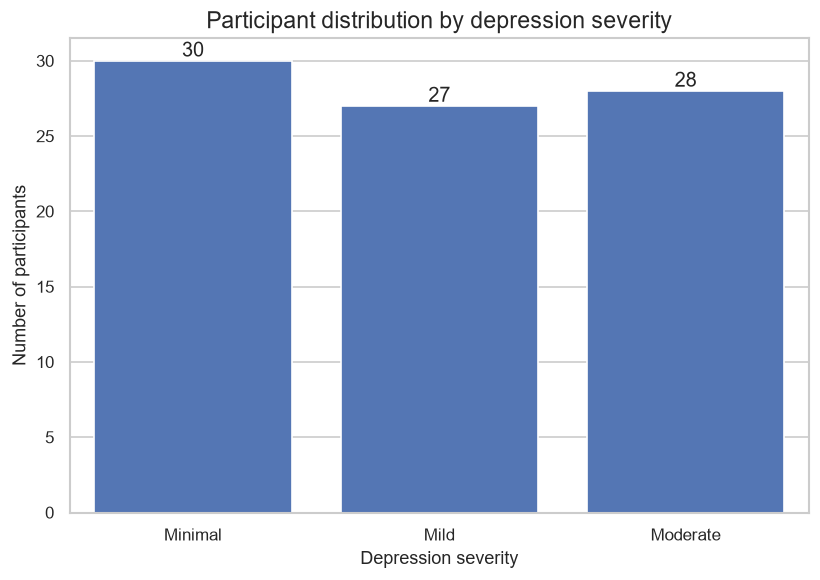

In [9]:
plot_df = final_df.copy()
plot_df["Label"] = plot_df["Group"].map(GROUP_LABELS)

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=plot_df, x="Label", order=LABEL_ORDER, color="#4472C4", ax=ax)
ax.set_title("Participant distribution by depression severity")
ax.set_xlabel("Depression severity")
ax.set_ylabel("Number of participants")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_class_distribution.png", bbox_inches="tight")
plt.show()


### 7.2 Gender Distribution

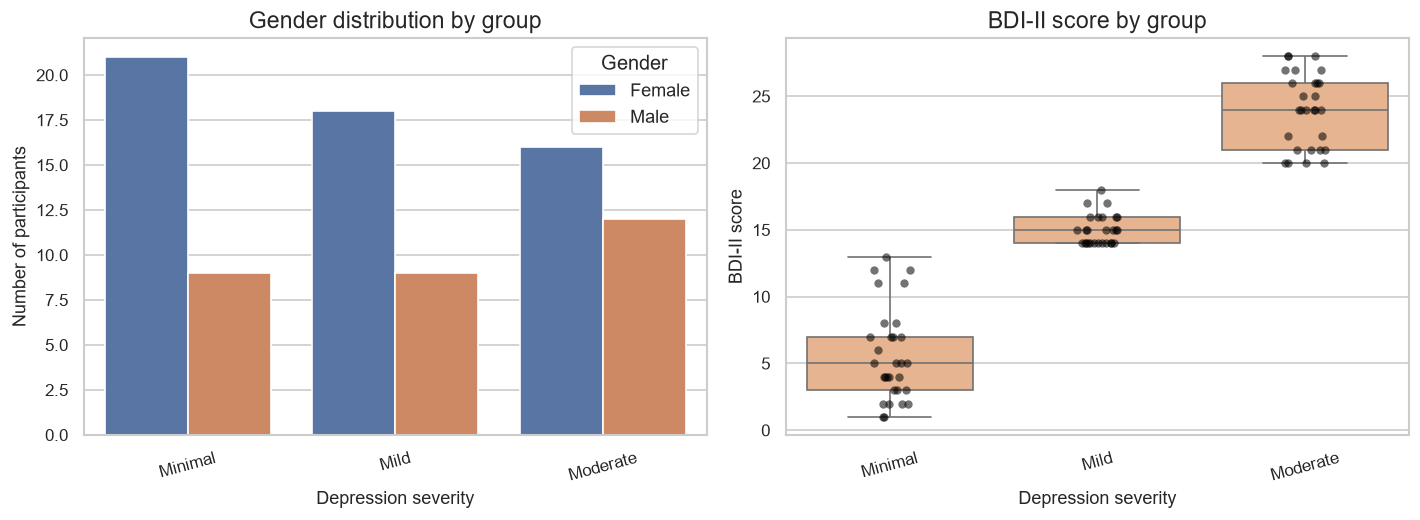

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=plot_df, x="Label", hue="Gender", order=LABEL_ORDER, ax=axes[0])
axes[0].set_title("Gender distribution by group")
axes[0].set_xlabel("Depression severity")
axes[0].set_ylabel("Number of participants")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=plot_df, x="Label", y="BDI_II", order=LABEL_ORDER, color="#F4B183", ax=axes[1])
sns.stripplot(data=plot_df, x="Label", y="BDI_II", order=LABEL_ORDER, color="black", alpha=0.55, ax=axes[1])
axes[1].set_title("BDI-II score by group")
axes[1].set_xlabel("Depression severity")
axes[1].set_ylabel("BDI-II score")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(FIG_DIR / "04_gender_and_bdi_by_group.png", bbox_inches="tight")
plt.show()


### 7.3 BDI-II and PHQ-9 Distributions

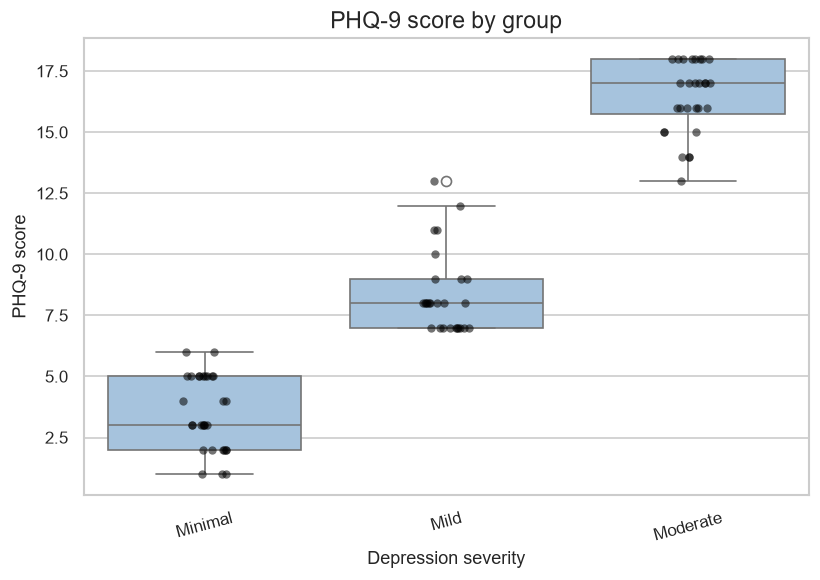

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_df, x="Label", y="PHQ9", order=LABEL_ORDER, color="#9DC3E6", ax=ax)
sns.stripplot(data=plot_df, x="Label", y="PHQ9", order=LABEL_ORDER, color="black", alpha=0.55, ax=ax)
ax.set_title("PHQ-9 score by group")
ax.set_xlabel("Depression severity")
ax.set_ylabel("PHQ-9 score")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(FIG_DIR / "05_phq9_by_group.png", bbox_inches="tight")
plt.show()


### 7.4 Missing Values

In [12]:
# Visualize missingness in the final participant-level table.
missing_final = final_df.isna().sum().sort_values(ascending=False)
missing_final = missing_final[missing_final > 0].head(30)

if len(missing_final):
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=missing_final.values, y=missing_final.index, color="#C00000", ax=ax)
    ax.set_title("Top missing-value counts in final dataset")
    ax.set_xlabel("Missing cells")
    ax.set_ylabel("Column")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "06_final_missing_values.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values in the final dataset.")


No missing values in the final dataset.


### 7.5 EEG Band Frequency

Available columns:
['E1-1', 'Group & ID', 'FP1', 'AF3', 'FPZ', 'FP2', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'O1', 'OZ', 'O2', 'Band']
Number of rows for each EEG band/feature:
Band
Delta (AP)     85
Theta (AP)     85
Alpha1 (AP)    85
Alpha2 (AP)    85
Beta (AP)      85
Delta(RP)      85
Theta(RP)      85
Alpha1(RP)     85
Alpha2(RP)     85
Beta(RP)       85
Name: count, dtype: int64


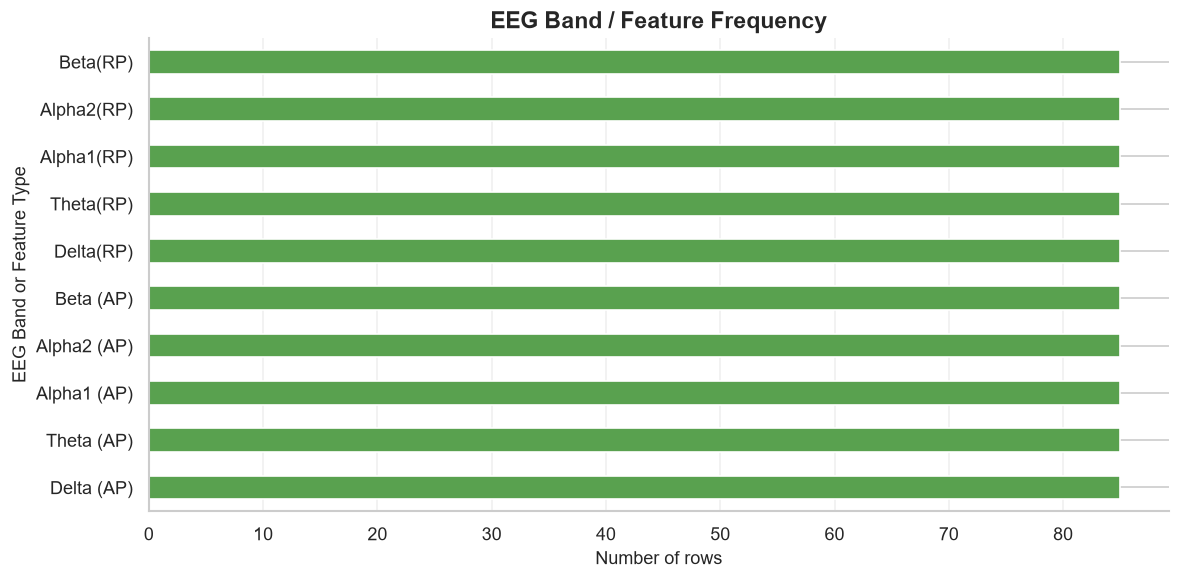

In [15]:
closed['Band'] = closed.iloc[:, 0].astype(str).str.strip()
closed = closed[closed['Band'] != 'Total (AP)'].copy()

print('Available columns:')
print(closed.columns.tolist())

if 'Band' not in closed.columns:
    print("closed['Band'] = closed.iloc[:, 0]")
else:
    band_counts = closed['Band'].value_counts()

    print('Number of rows for each EEG band/feature:')
    print(band_counts)

    plt.figure(figsize=(10, 5))
    band_counts.sort_values(ascending=True).plot(
        kind='barh',
        color='#59A14F'
    )

    plt.title('EEG Band / Feature Frequency')
    plt.xlabel('Number of rows')
    plt.ylabel('EEG Band or Feature Type')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


### 7.6 Outlier Analysis

In [16]:

excluded_columns = [
    'Group & ID',
    'Group',
    'Label',
    'Gender',
    'BDI_II',
    'PHQ9'
]

feature_columns = [
    column for column in final_df.columns
    if column not in excluded_columns
]

eda_features = final_df[feature_columns].apply(
    pd.to_numeric,
    errors='coerce'
)

Q1 = eda_features.quantile(0.25)
Q3 = eda_features.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outlier_mask = (
    (eda_features < lower_limit) |
    (eda_features > upper_limit)
)

outlier_count = outlier_mask.sum()
outlier_percent = (outlier_count / len(eda_features)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_count,
    'Outlier Percentage': outlier_percent
})

outlier_summary = outlier_summary.sort_values(
    'Outlier Percentage',
    ascending=False
)

print('Top 20 EEG features with the highest outlier percentage:')
display(outlier_summary.head(20))


Top 20 EEG features with the highest outlier percentage:


,Outlier Count,Outlier Percentage
F8_ Delta (AP),23,27.058824
O1_ Beta (AP),16,18.823529
PO3_ Beta (AP),15,17.647059
PO5_ Beta (AP),15,17.647059
F1_ Beta(RP),15,17.647059
CP2_ Beta (AP),15,17.647059
PO6_ Beta (AP),14,16.470588
F1_ Beta (AP),14,16.470588
P6_ Beta (AP),14,16.470588
T7_ Delta(RP),14,16.470588


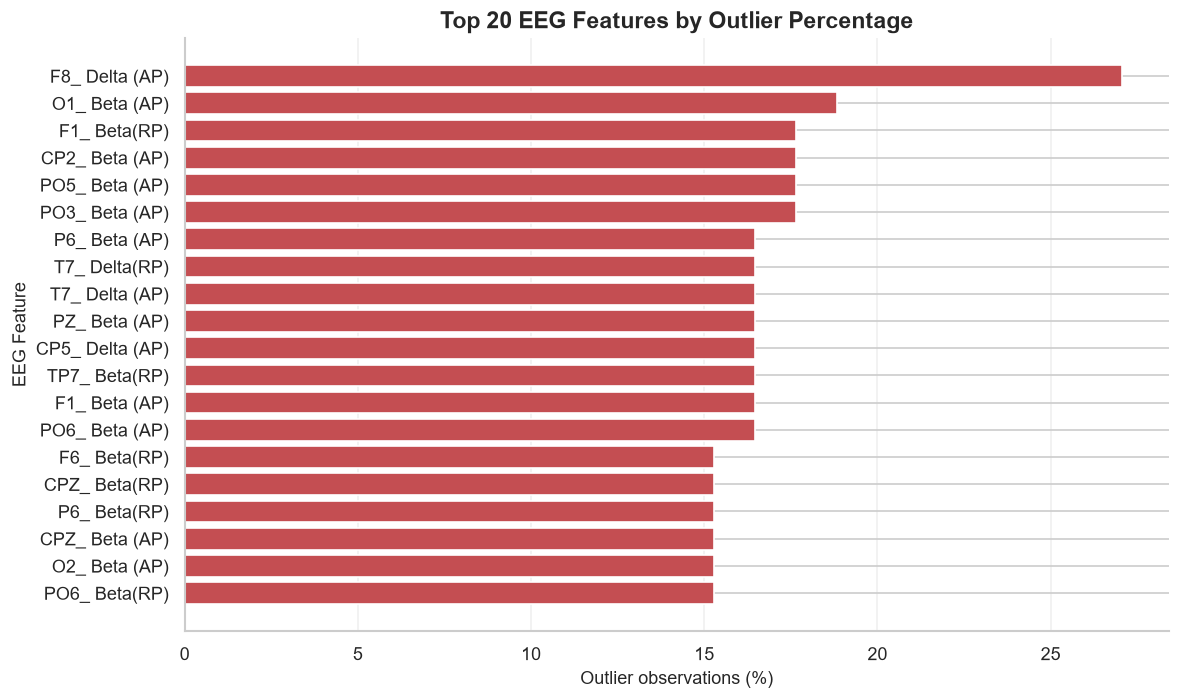

In [17]:

top_outliers = outlier_summary.head(20).sort_values(
    'Outlier Percentage',
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_outliers.index,
    top_outliers['Outlier Percentage'],
    color='#C44E52'
)

plt.title('Top 20 EEG Features by Outlier Percentage')
plt.xlabel('Outlier observations (%)')
plt.ylabel('EEG Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 7.7 Correlation Analysis

In [18]:

feature_correlation = eda_features.corr(method='spearman')

mean_absolute_correlation = (
    feature_correlation
    .abs()
    .replace(1.0, np.nan)
    .mean(axis=0)
    .sort_values(ascending=False)
)

print('Top 20 EEG features by mean absolute correlation:')
display(
    mean_absolute_correlation
    .head(20)
    .to_frame('Mean Absolute Spearman Correlation')
)


Top 20 EEG features by mean absolute correlation:


,Mean Absolute Spearman Correlation
CZ_ Alpha2(RP),0.329428
C1_ Alpha2(RP),0.328121
CPZ_ Alpha2(RP),0.322031
FC3_ Alpha2(RP),0.319112
PO3_ Alpha2(RP),0.318606
F3_ Alpha2(RP),0.316928
F5_ Alpha2(RP),0.316860
FC1_ Alpha2(RP),0.316840
FC5_ Alpha2(RP),0.315588
F1_ Alpha2(RP),0.314705


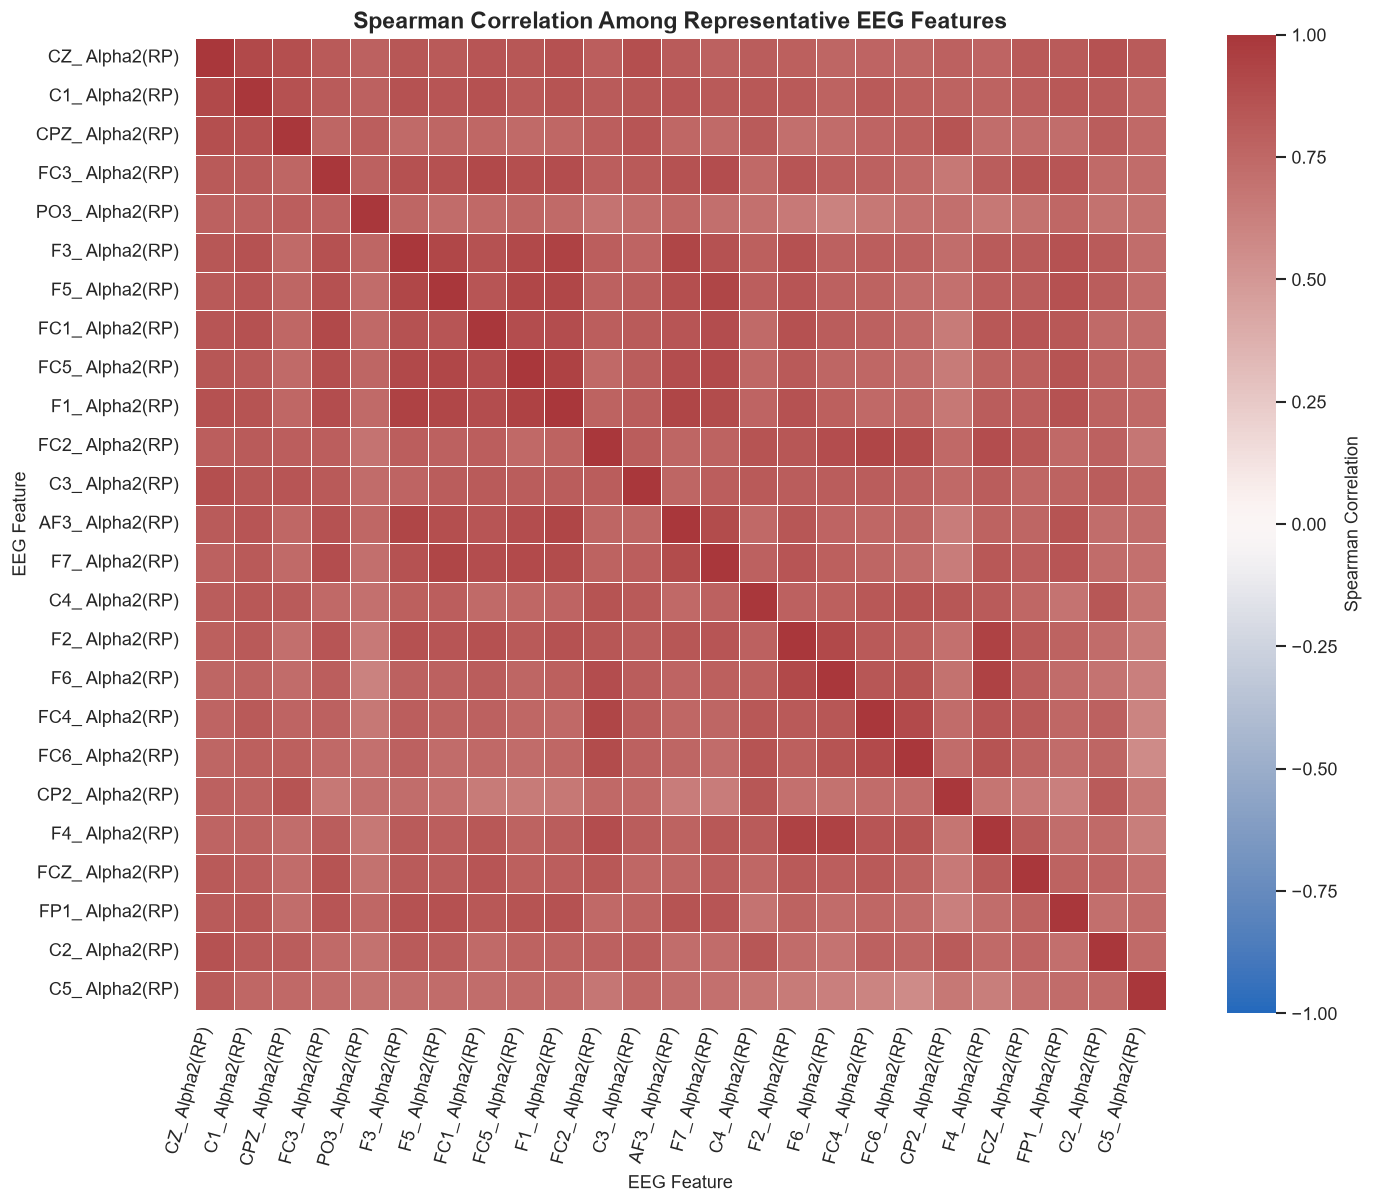

In [19]:

selected_features = mean_absolute_correlation.head(25).index

small_correlation_matrix = feature_correlation.loc[
    selected_features,
    selected_features
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    small_correlation_matrix,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Spearman Correlation'}
)

plt.title('Spearman Correlation Among Representative EEG Features')
plt.xlabel('EEG Feature')
plt.ylabel('EEG Feature')
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [20]:

upper_triangle = feature_correlation.where(
    np.triu(
        np.ones(feature_correlation.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
    .rename('Spearman Correlation')
    .to_frame()
)

print('Number of feature pairs with correlation >= 0.90:')
print(
    (high_correlation_pairs['Spearman Correlation'] >= 0.90).sum()
)

print('\nTop 20 highly correlated feature pairs:')
display(high_correlation_pairs.head(20))


Number of feature pairs with correlation >= 0.90:
204

Top 20 highly correlated feature pairs:


Spearman Correlation
F5_ Alpha2 (AP)  F7_ Alpha2 (AP)               0.998011
F4_ Alpha2 (AP)  F6_ Alpha2 (AP)               0.995666
F2_ Alpha2 (AP)  F4_ Alpha2 (AP)               0.990638
                 F6_ Alpha2 (AP)               0.989386
AF3_ Alpha2 (AP) F5_ Alpha2 (AP)               0.982412
                 F7_ Alpha2 (AP)               0.980320
PO5_ Alpha2 (AP) PO7_ Alpha2 (AP)              0.977994
F4_ Beta (AP)    F6_ Beta (AP)                 0.977876
P1_ Delta (AP)   P1_ Delta(RP)                 0.977395
PO4_ Delta (AP)  PO4_ Delta(RP)                0.972048
OZ_ Delta (AP)   OZ_ Delta(RP)                 0.971594
CP1_ Delta (AP)  CP1_ Delta(RP)                0.971374
P2_ Delta (AP)   P2_ Delta(RP)                 0.969784
CP3_ Delta (AP)  CP3_ Delta(RP)                0.969706
PO8_ Delta (AP)  PO8_ Delta(RP)                0.965992
C6_ Delta (AP)   C6_ Delta(RP)                 0.965092
F5_ Alpha2 (AP)  FC5_ Alpha2 (AP)              0.964810
PO3_ Delta (AP)  PO3_ Delta(RP)                0.964487
POZ_ Delta (AP)  POZ_ Delta(RP)                0.964342
FC2_ Delta (AP)  FC2_ Delta(RP)                0.963978

### 7.8 EEG Feature Heatmap

In [21]:

excluded_columns = [
    'Group & ID',
    'Group',
    'Label',
    'Gender',
    'BDI_II',
    'PHQ9'
]

feature_columns = [
    column for column in final_df.columns
    if column not in excluded_columns
]

heatmap_features = final_df[feature_columns].apply(
    pd.to_numeric,
    errors='coerce'
)


heatmap_data = pd.concat(
    [final_df[['Group']], heatmap_features],
    axis=1
)

mean_features_by_group = heatmap_data.groupby('Group').mean()

mean_features_by_group.index = mean_features_by_group.index.map({
    1: 'Minimal',
    2: 'Mild',
    3: 'Moderate'
})

print('Shape of group-wise mean table:')
print(mean_features_by_group.shape)

display(mean_features_by_group.iloc[:, :10])


Shape of group-wise mean table:
(3, 600)


,AF3_ Alpha1 (AP),AF3_ Alpha1(RP),AF3_ Alpha2 (AP),AF3_ Alpha2(RP),AF3_ Beta (AP),AF3_ Beta(RP),AF3_ Delta (AP),AF3_ Delta(RP),AF3_ Theta (AP),AF3_ Theta(RP)
Group,,,,,,,,,,
Minimal,9.049467,22.609560,10.872500,27.267559,15.217800,36.875970,1.375467,3.463423,4.146267,10.324315
Mild,9.297815,23.552792,11.008963,27.904978,13.434519,33.740933,1.571111,3.933036,4.304000,10.868261
Moderate,9.299250,22.567028,10.842464,26.342552,15.030000,36.056464,1.384321,3.350408,4.841500,11.683549


In [22]:

feature_standard_deviation = mean_features_by_group.std(axis=0)
feature_standard_deviation = feature_standard_deviation.replace(0, np.nan)

standardized_group_means = (
    mean_features_by_group - mean_features_by_group.mean(axis=0)
) / feature_standard_deviation

feature_variation = (
    standardized_group_means
    .abs()
    .max(axis=0)
    .sort_values(ascending=False)
)

top_features = feature_variation.head(30).index

print('Number of features selected for visualization:', len(top_features))
print('Selected features:')
print(top_features.tolist())


Number of features selected for visualization: 30
Selected features:
['FCZ_ Theta(RP)', 'CP1_ Theta(RP)', 'T8_ Alpha1(RP)', 'TP7_ Theta (AP)', 'FZ_ Beta (AP)', 'C4_ Alpha1 (AP)', 'AF3_ Alpha1 (AP)', 'P6_ Beta(RP)', 'FCZ_ Alpha2 (AP)', 'P8_ Beta(RP)', 'C4_ Beta(RP)', 'POZ_ Theta(RP)', 'O2_ Alpha1 (AP)', 'P1_ Delta(RP)', 'F7_ Alpha2 (AP)', 'C2_ Alpha1 (AP)', 'FC3_ Beta (AP)', 'F5_ Alpha2 (AP)', 'F8_ Delta (AP)', 'F7_ Delta(RP)', 'CP3_ Theta (AP)', 'CP2_ Beta(RP)', 'CP1_ Alpha2 (AP)', 'T8_ Alpha2 (AP)', 'CP6_ Alpha2(RP)', 'FZ_ Delta (AP)', 'PO3_ Beta(RP)', 'P4_ Beta (AP)', 'FT8_ Delta(RP)', 'P7_ Delta(RP)']


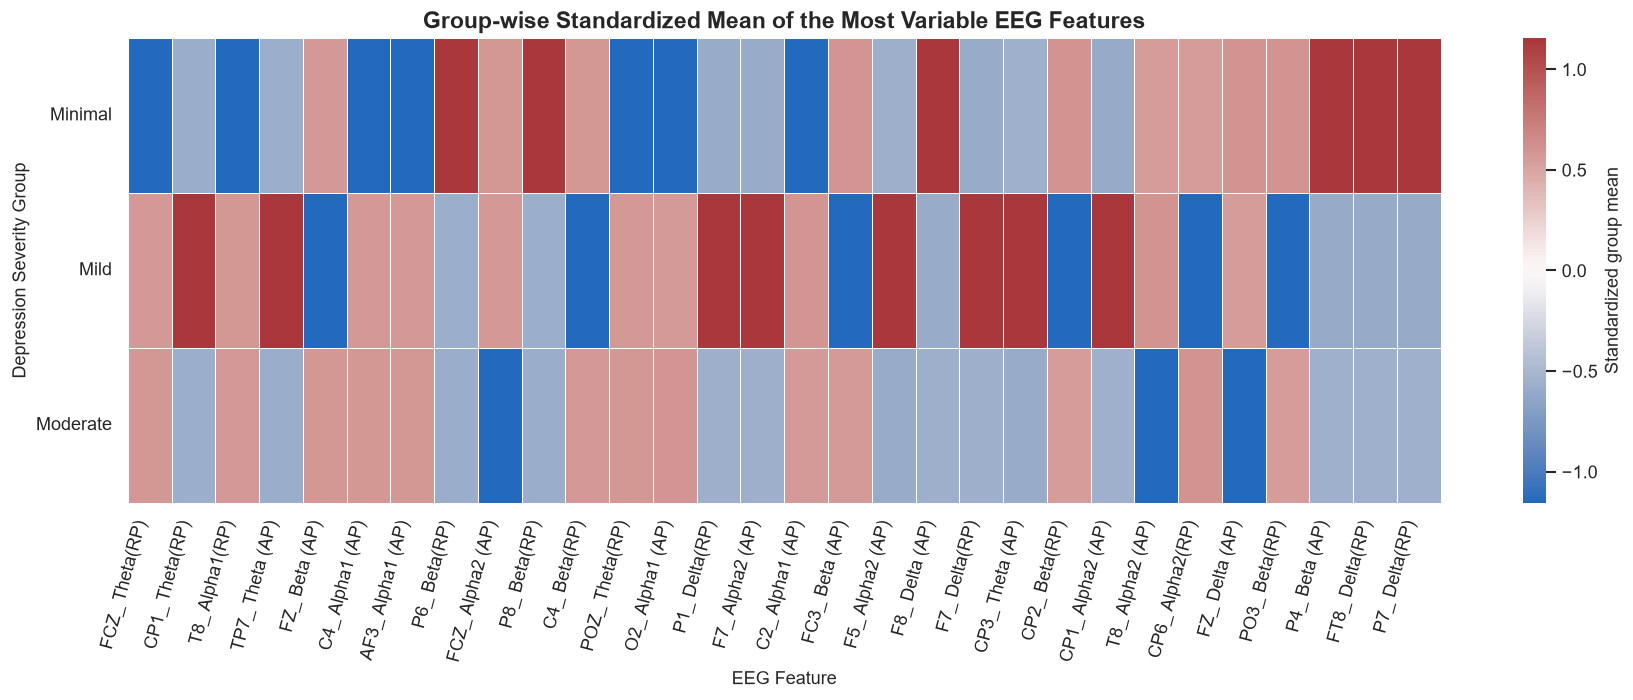

In [23]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    standardized_group_means.loc[:, top_features],
    cmap='vlag',
    center=0,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Standardized group mean'}
)

plt.title('Group-wise Standardized Mean of the Most Variable EEG Features')
plt.xlabel('EEG Feature')
plt.ylabel('Depression Severity Group')
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 8.Export Modeling Dataset

In [28]:
final_df.to_csv(OUTPUT_FILE, index=False)

print(f'Saved file: {OUTPUT_FILE}')
print('Final shape:', final_df.shape)
print('Final labels:')
print(final_df['Group'].value_counts().sort_index())
print("Figures saved in:", FIG_DIR.resolve())



Saved file: final_df.csv
Final shape: (85, 606)
Final labels:
Group
1    30
2    27
3    28
Name: count, dtype: int64
Figures saved in: D:\EEG_Depression_Project\eda_figures
